In [1]:
!pip install tensorflow

In [2]:
!pip install nlp-id Sastrawi

1. LOAD DATASET & CLEANING BARIS KOSONG PADA KOLOM

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

df = pd.read_csv('dataset.csv')
df.head()

,text,date,sentiment
0,ini menjijikkan,2025-11-01,Negative
1,ini kurang lengkap,2025-11-02,Negative
2,penting untuk dipertimbangkan dengan hatihati,2025-11-03,Positive
3,apa pendapat anda tentang ini saya sedikit bin...,2025-11-04,Negative
4,saya senang dengan hasilnya,2025-11-05,Positive


In [4]:
df = df.dropna(subset=['text', 'date']).reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).reset_index(drop=True)

EDA

/tmp/ipykernel_1691/3036214491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


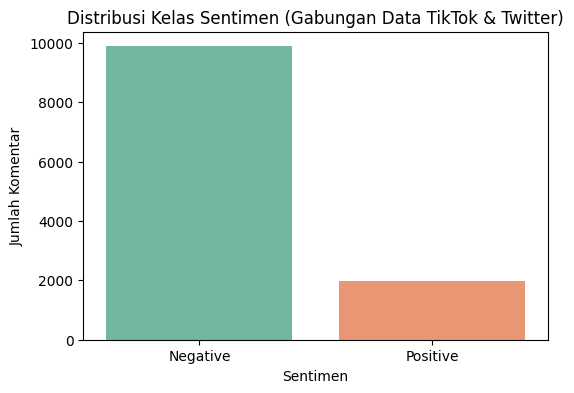

Detail Jumlah Data per Kelas:
sentiment
Negative    9884
Positive    1977
Name: count, dtype: int64


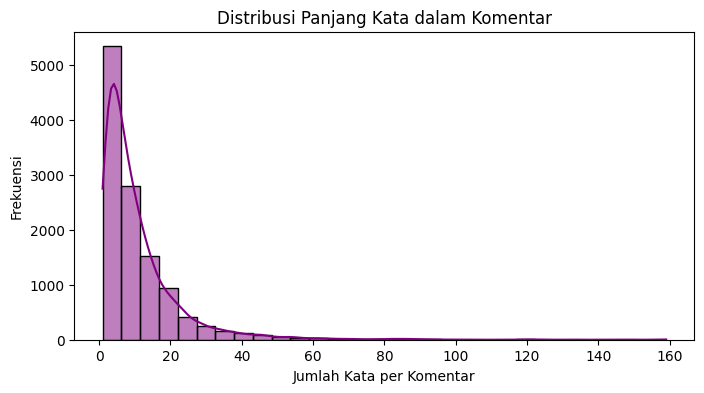

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Distribusi Kelas Sentimen (Gabungan Data TikTok & Twitter)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Komentar')
plt.show()

print("Detail Jumlah Data per Kelas:")
print(df['sentiment'].value_counts())

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,4))
sns.histplot(df['word_count'], bins=30, kde=True, color='purple')
plt.title('Distribusi Panjang Kata dalam Komentar')
plt.xlabel('Jumlah Kata per Komentar')
plt.ylabel('Frekuensi')
plt.show()

DATA AUGMENTASI

In [6]:
def random_deletion(text, p=0.2):
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [word for word in words if random.uniform(0, 1) > p]
    if len(new_words) == 0:
        return words[random.randint(0, len(words)-1)]
    return ' '.join(new_words)

positive_df = df[df['sentiment'] == 'Positive'].copy()

augmented_records = []
for index, row in positive_df.iterrows():
    aug_text_1 = random_deletion(row['text'], p=0.15)
    aug_text_2 = random_deletion(row['text'], p=0.20)

    augmented_records.append({'text': aug_text_1, 'date': row['date'], 'sentiment': 'Positive'})
    augmented_records.append({'text': aug_text_2, 'date': row['date'], 'sentiment': 'Positive'})

df_augmented = pd.concat([df, pd.DataFrame(augmented_records)], ignore_index=True)
print("Jumlah data setelah Data Augmentation:")
print(df_augmented['sentiment'].value_counts())

Jumlah data setelah Data Augmentation:
sentiment
Negative    9884
Positive    5931
Name: count, dtype: int64


DATA PREPROCESSING MENGGUNAKAN LEMMATIZATION & EMBEDDING

In [7]:
from nlp_id.lemmatizer import Lemmatizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = stopword_factory.get_stop_words()
lemmatizer = Lemmatizer()

def text_preprocessing(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'https?://\S+|www\.\S+||@\w+||#\w+|\d+|[^\w\s]', '', text)
    text = text.lower()
    tokens = text.split()
    tokens = [w for w in tokens if w not in indonesian_stopwords]
    clean_sentence = " ".join(tokens)
    return lemmatizer.lemmatize(clean_sentence)

print("Menjalankan Lemmatization...")
df_augmented['clean_text'] = df_augmented['text'].apply(text_preprocessing)

MAX_WORDS = 5000
MAX_LEN = 50
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_augmented['clean_text'])

X = pad_sequences(tokenizer.texts_to_sequences(df_augmented['clean_text']), maxlen=MAX_LEN, padding='post')
y = pd.get_dummies(df_augmented['sentiment']).values

label_mapping = {'Negative': -1, 'Positive': 1}
df_augmented['sentiment_numeric'] = df_augmented['sentiment'].map(label_mapping).fillna(0)

Menjalankan Lemmatization...


In [8]:
df_augmented.to_csv('df_augmented.csv', index=False)

TRAINING MODEL ANALISIS SENTIMEN HYBRID CNN-LSTM

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

NUM_CLASSES = y.shape[1]

model_sentimen = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(NUM_CLASSES, activation='softmax')
])

model_sentimen.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Memulai training model analisis sentimen...")
history_sentimen = model_sentimen.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Memulai training model analisis sentimen...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.8014 - loss: 0.4165 - val_accuracy: 0.9336 - val_loss: 0.1952
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9561 - loss: 0.1444 - val_accuracy: 0.9504 - val_loss: 0.1449
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9734 - loss: 0.0924 - val_accuracy: 0.9595 - val_loss: 0.1127
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9817 - loss: 0.0671 - val_accuracy: 0.9671 - val_loss: 0.1099
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9864 - loss: 0.0553 - val_accuracy: 0.9674 - val_loss: 0.1338
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9876 - loss: 0.0470 - val_accuracy: 0.9605 - val_loss: 0.1370
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9891 - loss: 0.0419 - val_accuracy: 0.9665 - val_loss: 0.1309
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9888 - loss: 0.0409 - val_accurac

Grafik Evaluasi Analisis Sentimen

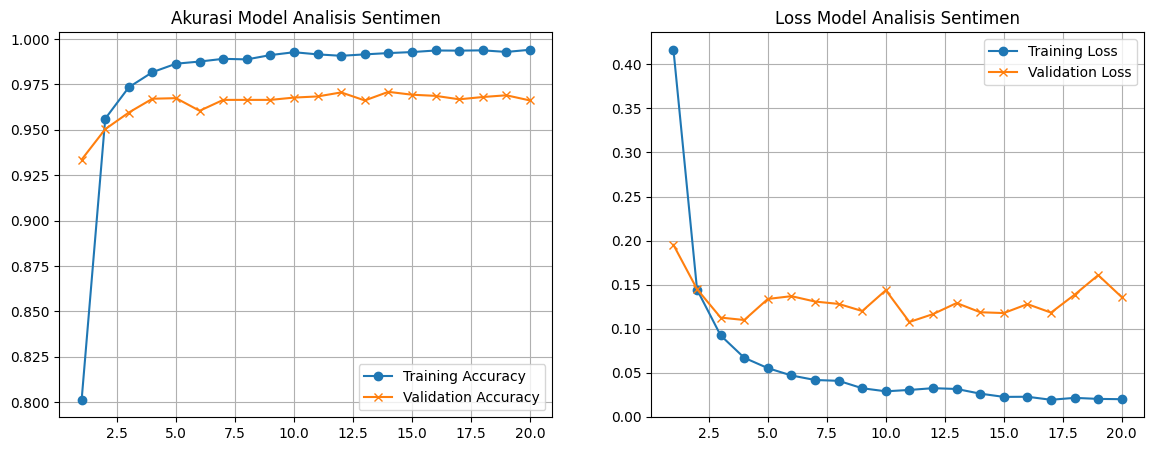

In [10]:
acc = history_sentimen.history['accuracy']
val_acc = history_sentimen.history['val_accuracy']
loss = history_sentimen.history['loss']
val_loss = history_sentimen.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.title('Akurasi Model Analisis Sentimen')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.title('Loss Model Analisis Sentimen')
plt.legend()
plt.grid(True)
plt.show()

AGREGASI WAKTU HARIAN

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df_augmented = pd.read_csv('df_augmented.csv')
df_augmented['date'] = pd.to_datetime(df_augmented['date'])

Hasil data runtun waktu harian (5 baris pertama):
            sentiment_numeric
date                         
2025-08-21          -1.000000
2025-08-22          -1.000000
2025-08-23          -1.000000
2025-08-24          -1.000000
2025-08-25          -0.461538


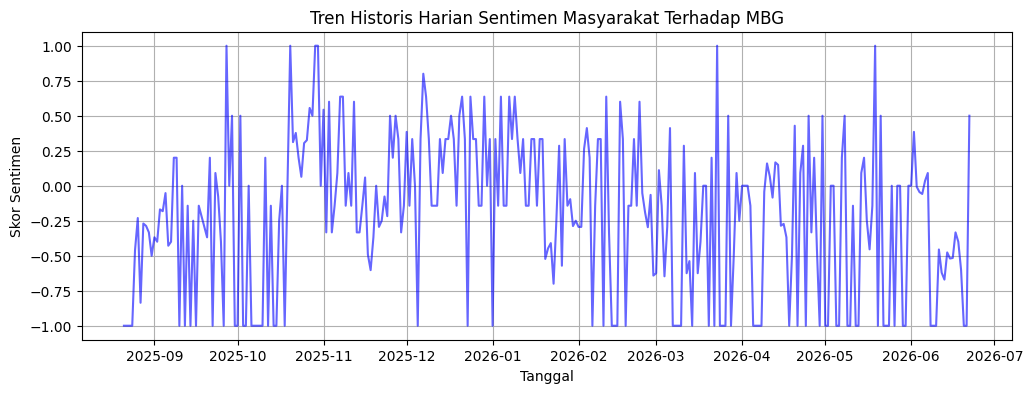

In [12]:
df_time = df_augmented.set_index('date')
data_harian = df_time['sentiment_numeric'].resample('D').mean().fillna(0).to_frame()

print("Hasil data runtun waktu harian (5 baris pertama):")
print(data_harian.head(5))

plt.figure(figsize=(12,4))
plt.plot(data_harian.index, data_harian['sentiment_numeric'], color='blue', alpha=0.6)
plt.title('Tren Historis Harian Sentimen Masyarakat Terhadap MBG')
plt.xlabel('Tanggal')
plt.ylabel('Skor Sentimen')
plt.grid(True)
plt.show()

In [13]:
import pandas as pd

df_time_sorted = df_time.sort_index(ascending=True)

df_analisis = df_time_sorted['sentiment_numeric'].resample('D').agg(['mean', 'size'])

df_analisis.columns = ['Rata-rata Sentiment', 'Banyak Data (Baris)']

df_analisis['Banyak Data (Baris)'] = df_analisis['Banyak Data (Baris)'].fillna(0).astype(int)
df_analisis['Rata-rata Sentiment'] = df_analisis['Rata-rata Sentiment'].fillna(0.0)

pd.set_option('display.max_rows', None)

print("=======================================================")
print("     DAFTAR BANYAK DATA & RATA-RATA SENTIMEN PER HARI  ")
print("=======================================================")
print(df_analisis)

pd.reset_option('display.max_rows')

     DAFTAR BANYAK DATA & RATA-RATA SENTIMEN PER HARI  
            Rata-rata Sentiment  Banyak Data (Baris)
date                                                
2025-08-21            -1.000000                    6
2025-08-22            -1.000000                    8
2025-08-23            -1.000000                    2
2025-08-24            -1.000000                    6
2025-08-25            -0.461538                  156
2025-08-26            -0.230769                  156
2025-08-27            -0.836066                  366
2025-08-28            -0.269962                  526
2025-08-29            -0.287129                  202
2025-08-30            -0.333333                   72
2025-08-31            -0.500000                   24
2025-09-01            -0.368421                   38
2025-09-02            -0.400000                  100
2025-09-03            -0.169231                  260
2025-09-04            -0.181818                  132
2025-09-05            -0.052632            

FORECASTING PREPARATION & HYBRID MODEL (CNN & LSTM )TRAINING

Forecasting terhadap data baru hingga 1 bulan kedepan

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================================
# 1. PERSIAPAN DATA
# =====================================================================
def create_forecasting_window(dataset, look_back=14):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Catatan: Jika data harianmu banyak, mengubah LOOK_BACK ke 30 atau 60
# akan sangat membantu model melihat tren jangka panjang agar tidak flatline.
LOOK_BACK = 14

df_proses = data_harian.copy()
df_proses['positif_tren'] = df_proses['sentiment_numeric'].apply(lambda x: x if x > 0 else 0.0)
df_proses['negatif_tren'] = df_proses['sentiment_numeric'].apply(lambda x: abs(x) if x < 0 else 0.0)

kategori_sentimen = ['positif_tren', 'negatif_tren']

model_tersimpan = {}
hasil_all = {}
history_tersimpan = {}

# =====================================================================
# 2. PROSES TRAINING (VERSI TUNING BALANCE)
# =====================================================================
for kolom in kategori_sentimen:
    nama_tampilan = "POSITIF" if kolom == 'positif_tren' else "NEGATIF"
    print("\n" + "="*80)
    print(f" PROSES TRAINING UNTUK SENTIMEN: {nama_tampilan} ")
    print("="*80)

    dataset_values = df_proses[[kolom]].values
    X_forecast, y_forecast = create_forecasting_window(dataset_values, LOOK_BACK)
    X_forecast = np.reshape(X_forecast, (X_forecast.shape[0], X_forecast.shape[1], 1))

    # Struktur model versi balance
    model_forecast = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(LOOK_BACK, 1)),
        MaxPooling1D(pool_size=2),
        LSTM(32, dropout=0.1),
        Dense(1)
    ])
    model_forecast.compile(optimizer='adam', loss='mean_squared_error')

    # Early stopping dengan kelonggaran lebih (patience=15)
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    print(f"Memulai training model harian untuk {nama_tampilan}...")
    history_forecast = model_forecast.fit(
        X_forecast, y_forecast,
        epochs=50,
        batch_size=4,
        verbose=1,
        validation_split=0.1,
        callbacks=[early_stop]
    )
    history_tersimpan[kolom] = history_forecast.history

    print("Menyimpan hasil prediksi historis...")
    y_pred_historis = model_forecast.predict(X_forecast, verbose=0).flatten()

    model_tersimpan[kolom] = model_forecast
    hasil_all[kolom] = {
        'aktual': dataset_values[LOOK_BACK:].flatten(),
        'historis': y_pred_historis,
        'dataset_values_asli': dataset_values
    }

    print(f"Training {nama_tampilan} Selesai!")


 PROSES TRAINING UNTUK SENTIMEN: POSITIF 
Memulai training model harian untuk POSITIF...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0562 - val_loss: 0.0147
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0563 - val_loss: 0.0261
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0554 - val_loss: 0.0177
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0566 - val_loss: 0.0196
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0538 - val_loss: 0.0204
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0545 - val_loss: 0.0176
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0530 - val_loss: 0.0237
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0569 - val_loss: 0.0135
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0546 - val_loss: 0.0193
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0534 - val_loss: 0.0163
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0531 - val_loss: 0.0187
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0538 - val_loss: 0.0140

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1674 - val_loss: 0.1962
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1468 - val_loss: 0.2043
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1432 - val_loss: 0.2081
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1466 - val_loss: 0.1970
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1496 - val_loss: 0.1953
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1445 - val_loss: 0.1956
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1422 - val_loss: 0.1957
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1460 - val_loss: 0.1991
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1413 - val_loss: 0.1980
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1427 - val_loss: 0.1988
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1429 - val_loss: 0.2002
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1397 - val_loss: 0.19

Memulai prediksi masa depan (30 hari) untuk POSITIF...
Prediksi POSITIF selesai!
Memulai prediksi masa depan (30 hari) untuk NEGATIF...
Prediksi NEGATIF selesai!

Menampilkan grafik terpisah...


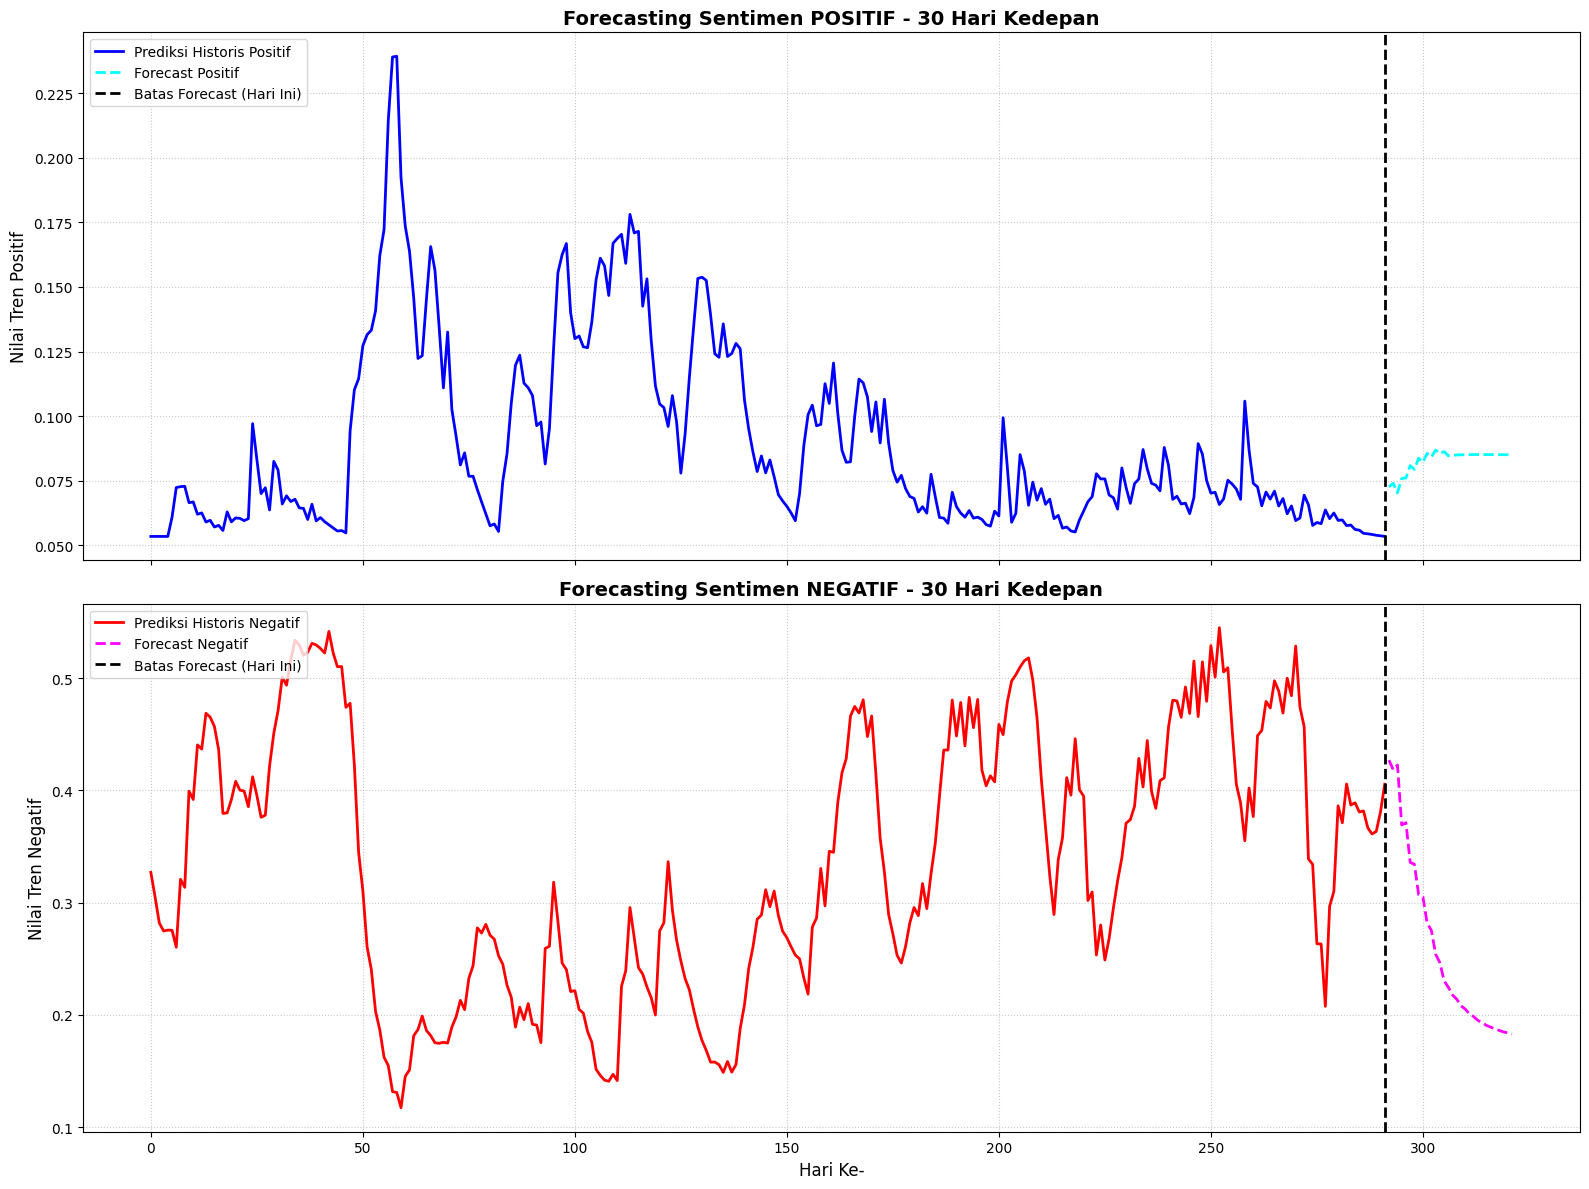

In [15]:
JUMLAH_HARI_FORECAST = 30

for kolom in ['positif_tren', 'negatif_tren']:
    nama_tampilan = "POSITIF" if kolom == 'positif_tren' else "NEGATIF"
    print(f"Memulai prediksi masa depan ({JUMLAH_HARI_FORECAST} hari) untuk {nama_tampilan}...")

    # Panggil model dan data asli dari proses training di Cell 1
    model_terlatih = model_tersimpan[kolom]
    dataset_values = hasil_all[kolom]['dataset_values_asli']

    # Ambil 14 hari terakhir dari data asli untuk pijakan awal
    last_window = dataset_values[-LOOK_BACK:]
    prediksi_masa_depan = []

    for _ in range(JUMLAH_HARI_FORECAST):
        current_window = np.reshape(last_window, (1, LOOK_BACK, 1))

        # Gunakan model_terlatih untuk memprediksi
        next_pred = model_terlatih.predict(current_window, verbose=0)[0][0]
        next_pred = max(0.0, next_pred)

        prediksi_masa_depan.append(next_pred)
        last_window = np.append(last_window[1:], [[next_pred]], axis=0)

    # Masukkan hasil forecast ke dalam dictionary
    hasil_all[kolom]['masa_depan'] = prediksi_masa_depan
    print(f"Prediksi {nama_tampilan} selesai!")

# =====================================================================
# 4. VISUALISASI HASIL FORECAST
# =====================================================================
print("\nMenampilkan grafik terpisah...")

panjang_data_historis = len(hasil_all['positif_tren']['historis'])
waktu_historis = np.arange(panjang_data_historis)
waktu_depan = np.arange(panjang_data_historis, panjang_data_historis + JUMLAH_HARI_FORECAST)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# GRAFIK 1: TREN POSITIF (ATAS)
ax1.plot(waktu_historis, hasil_all['positif_tren']['historis'], label='Prediksi Historis Positif', color='blue', linewidth=2)
ax1.plot(waktu_depan, hasil_all['positif_tren']['masa_depan'], label='Forecast Positif', color='cyan', linestyle='dashed', linewidth=2)
ax1.axvline(x=panjang_data_historis - 1, color='black', linestyle='--', linewidth=2, label='Batas Forecast (Hari Ini)')
ax1.set_title(f'Forecasting Sentimen POSITIF - {JUMLAH_HARI_FORECAST} Hari Kedepan', fontsize=14, fontweight='bold')
ax1.set_ylabel('Nilai Tren Positif', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.7)

# GRAFIK 2: TREN NEGATIF (BAWAH)
ax2.plot(waktu_historis, hasil_all['negatif_tren']['historis'], label='Prediksi Historis Negatif', color='red', linewidth=2)
ax2.plot(waktu_depan, hasil_all['negatif_tren']['masa_depan'], label='Forecast Negatif', color='magenta', linestyle='dashed', linewidth=2)
ax2.axvline(x=panjang_data_historis - 1, color='black', linestyle='--', linewidth=2, label='Batas Forecast (Hari Ini)')
ax2.set_title(f'Forecasting Sentimen NEGATIF - {JUMLAH_HARI_FORECAST} Hari Kedepan', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hari Ke-', fontsize=12)
ax2.set_ylabel('Nilai Tren Negatif', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

GRAFIK EVALUASI LOSS FORECASTING

Menampilkan grafik evaluasi loss...


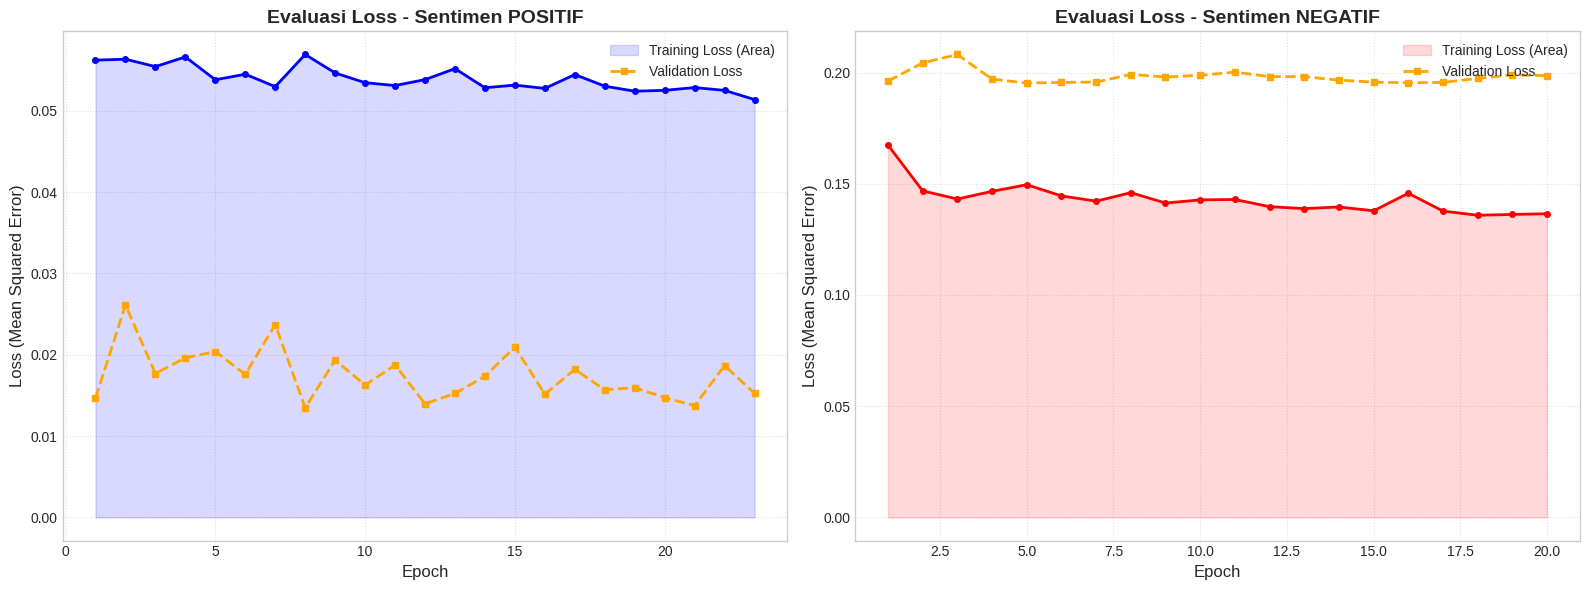

In [16]:
import matplotlib.pyplot as plt

# VISUALISASI EVALUASI LOSS (TRAINING VS VALIDATION) - VERSI MODERN CHART
print("Menampilkan grafik evaluasi loss...")

# Mengaktifkan style clean grid agar chart terlihat profesional
plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------------------
# GRAFIK 1: LOSS POSITIF (KIRI)
# ---------------------------------------------------------------------
hist_pos = history_tersimpan['positif_tren']
epoch_range_pos = range(1, len(hist_pos['loss']) + 1)

# Membuat Area Chart dengan fill_between
ax1.fill_between(epoch_range_pos, hist_pos['loss'], color='blue', alpha=0.15, label='Training Loss (Area)')
ax1.plot(epoch_range_pos, hist_pos['loss'], color='blue', linewidth=2, marker='o', markersize=4)
ax1.plot(epoch_range_pos, hist_pos['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--', marker='s', markersize=4)

ax1.set_title('Evaluasi Loss - Sentimen POSITIF', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Mean Squared Error)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# ---------------------------------------------------------------------
# GRAFIK 2: LOSS NEGATIF (KANAN)
# ---------------------------------------------------------------------
hist_neg = history_tersimpan['negatif_tren']
epoch_range_neg = range(1, len(hist_neg['loss']) + 1)

# Membuat Area Chart dengan fill_between
ax2.fill_between(epoch_range_neg, hist_neg['loss'], color='red', alpha=0.15, label='Training Loss (Area)')
ax2.plot(epoch_range_neg, hist_neg['loss'], color='red', linewidth=2, marker='o', markersize=4)
ax2.plot(epoch_range_neg, hist_neg['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--', marker='s', markersize=4)

ax2.set_title('Evaluasi Loss - Sentimen NEGATIF', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (Mean Squared Error)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

VISUALISASI GRAFIK TREN AKHIR

Menyiapkan Visualisasi Tren Akhir...


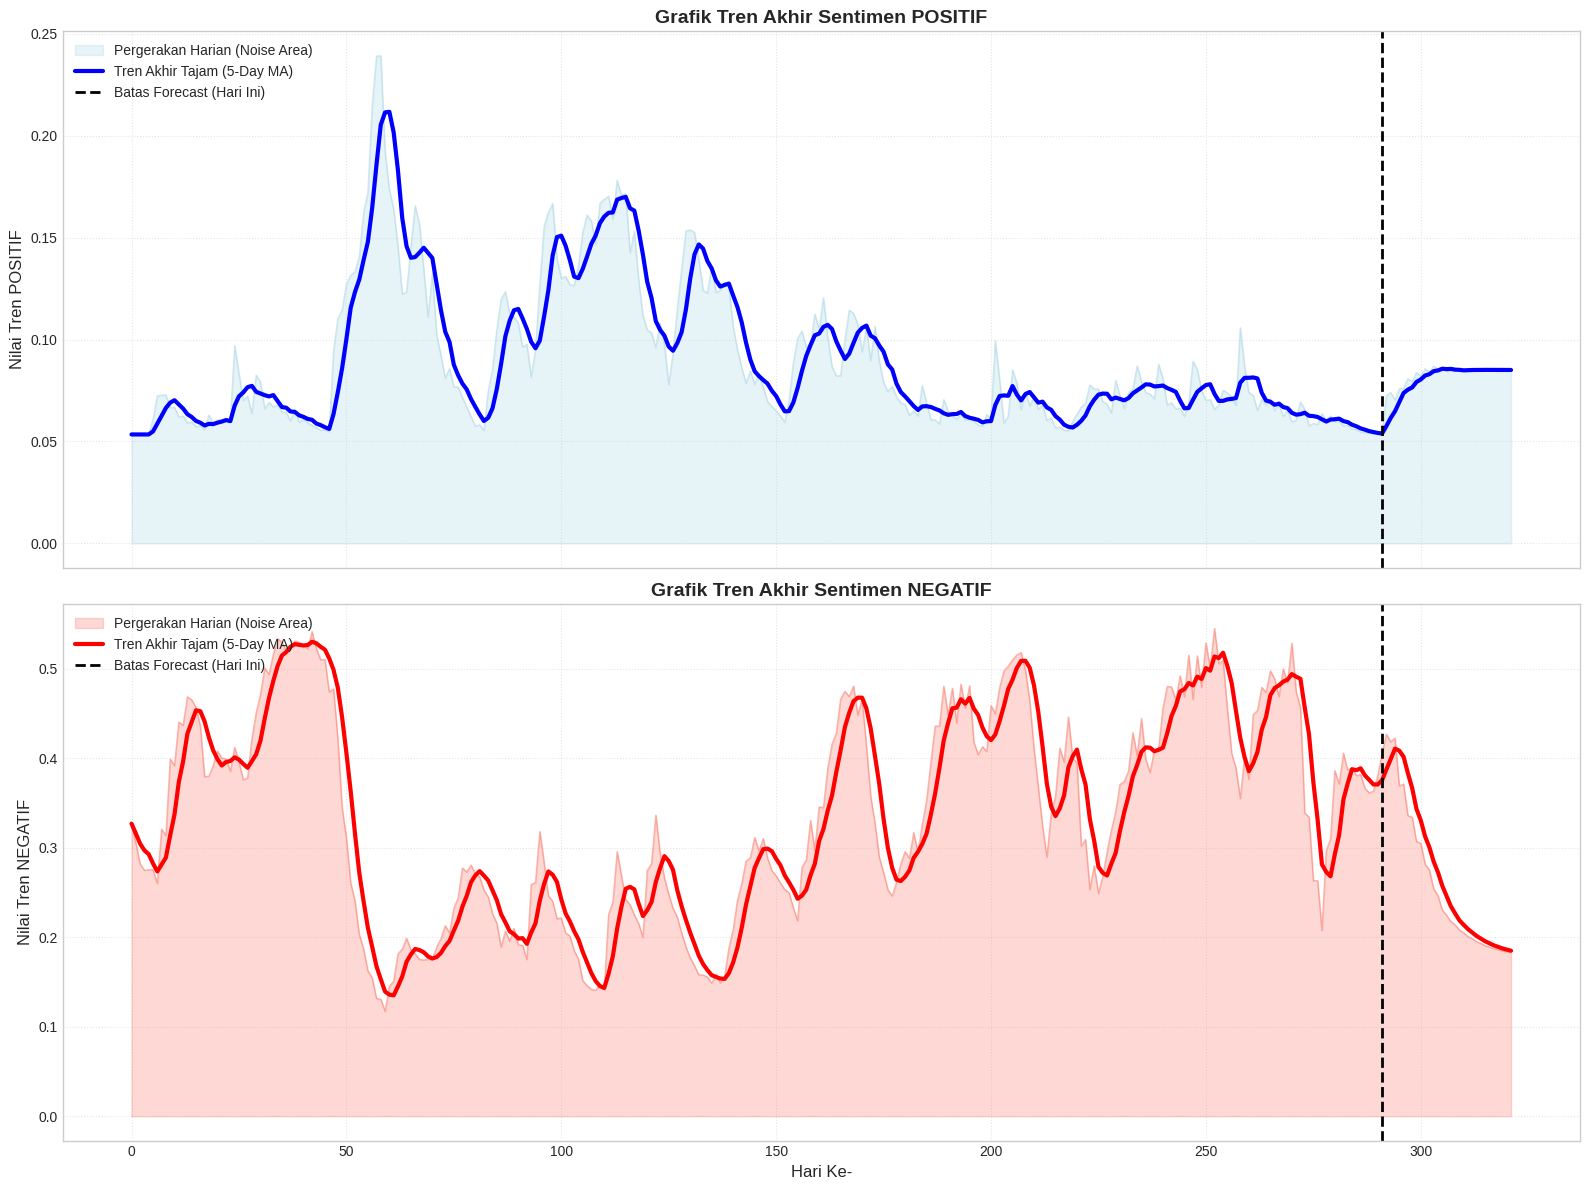

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# VISUALISASI GRAFIK TREN AKHIR (COMBINATION AREA, SHARP TREND & DAILY NOISE)
print("Menyiapkan Visualisasi Tren Akhir...")

# DIUBAH KE 5: Agar garis tren akhir tidak landai/halus, melainkan tajam mengikuti harian
WINDOW_MA = 5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

for ax, kolom, warna_asli, warna_tren, judul in zip(
    [ax1, ax2],
    ['positif_tren', 'negatif_tren'],
    ['lightblue', 'salmon'],  # Warna untuk pergerakan harian & bayangannya
    ['blue', 'red'],          # Warna utama untuk garis tren yang tajam
    ['POSITIF', 'NEGATIF']
):
    # Mengambil data dari dictionary hasil_all
    data_historis = hasil_all[kolom]['historis']
    data_depan = hasil_all[kolom]['masa_depan']

    # Menggabungkan data historis dan masa depan menjadi satu Series berurutan
    gabungan_data = np.concatenate([data_historis, data_depan])
    gabungan_series = pd.Series(gabungan_data)

    # Menghitung Tren yang bergerak tajam (Short-term Moving Average)
    data_tren = gabungan_series.rolling(window=WINDOW_MA, min_periods=1).mean()

    # Menentukan sumbu X
    total_hari = len(gabungan_data)
    waktu_all = np.arange(total_hari)

    ax.fill_between(waktu_all, gabungan_data, color=warna_asli, alpha=0.3, label='Pergerakan Harian (Noise Area)')
    ax.plot(waktu_all, gabungan_data, color=warna_asli, linewidth=1, alpha=0.5)

    ax.plot(waktu_all, data_tren, color=warna_tren, linewidth=3, label=f'Tren Akhir Tajam ({WINDOW_MA}-Day MA)')

    # Garis Pembagi Masa Lalu & Masa Depan
    batas_hari_ini = len(data_historis) - 1
    ax.axvline(x=batas_hari_ini, color='black', linestyle='--', linewidth=2, label='Batas Forecast (Hari Ini)')

    # Kosmetik Grafik
    ax.set_title(f'Grafik Tren Akhir Sentimen {judul}', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'Nilai Tren {judul}', fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)

# Label sumbu X hanya di grafik paling bawah
ax2.set_xlabel('Hari Ke-', fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
# PEMBUKTIAN JUMLAH HARI FORECAST
print("=== CEK JUMLAH DATA MASA DEPAN ===")
print("Jumlah hari forecast POSITIF :", len(hasil_all['positif_tren']['masa_depan']), "hari")
print("Jumlah hari forecast NEGATIF :", len(hasil_all['negatif_tren']['masa_depan']), "hari")

=== CEK JUMLAH DATA MASA DEPAN ===
Jumlah hari forecast POSITIF : 30 hari
Jumlah hari forecast NEGATIF : 30 hari


In [ ]:
print("Memulai proses penyimpanan model ganda...")
folder_simpan = "model_forecasting_tersimpan"
if not os.path.exists(folder_simpan):
    os.makedirs(folder_simpan)

for kolom, model in model_tersimpan.items():
    nama_sentimen = "positif" if kolom == 'positif_tren' else "negatif"

    file_keras = f"{folder_simpan}/model_cnn_lstm_{nama_sentimen}.keras"
    model.save(file_keras)
    print(f"✅ Tersimpan (.keras): {file_keras}")

    file_h5 = f"{folder_simpan}/model_cnn_lstm_{nama_sentimen}.h5"
    model.save(file_h5)
    print(f"✅ Tersimpan (.h5)   : {file_h5}")

print("\nSemua model sudah aman tersimpan dalam dua format!")

Memulai proses penyimpanan model ganda...
✅ Tersimpan (.keras): model_forecasting_tersimpan/model_cnn_lstm_positif.keras
✅ Tersimpan (.h5)   : model_forecasting_tersimpan/model_cnn_lstm_positif.h5
✅ Tersimpan (.keras): model_forecasting_tersimpan/model_cnn_lstm_negatif.keras
✅ Tersimpan (.h5)   : model_forecasting_tersimpan/model_cnn_lstm_negatif.h5

Semua model sudah aman tersimpan dalam dua format!
